In [ ]:
from pathlib import Path

from backtest_util import *
import backtest_XGB

EXPERIMENT    = "full_dataset"       # matches results/final_<NAME>_reg.ubj
SECTORS       =  None#[EXPERIMENT]        # None = all sectors
TOP_QUANTILE  = 0.2
BOT_QUANTILE  = 0                # 0 = long-only
REBALANCE     = "fixed"               # "fixed" | "staggered"
MIN_STOCKS    = 3
OUTPUT_DIR    = Path("backtest_results_v2")

GPU detected: NVIDIA GeForce GTX 1070, 8192 MiB


In [ ]:
df = load_dataset(SECTORS)
START, END = infer_test_window(df)
print(f"Test window: {START}  →  {END}")

Dataset: 25,931 rows | 602 tickers
Test window: 2023-03-31  →  2026-03-15


Loaded ensemble [financial_services]  (3 models | train IC=0.0934) ICIR=1.5346
Dataset: 25,931 rows | 602 tickers

Backtest  2023Q1 → 2026Q1  (13 Qs)  mode=fixed  long=20%  short=0%

Sector baseline ETF: XLF


Quarters:   0%|          | 0/12 [00:00<?, ?it/s]

2023Q1 n=533→107 long=+1.69%  comb=+1.69% SPY≈+8.68% sector≈+5.32% alpha=-6.99% IC(Batch)=+0.104
  [retrain] ensemble member 0: fit on 392 rows
  [retrain] ensemble member 1: fit on 398 rows
  [retrain] ensemble member 2: fit on 391 rows
2023Q2 n=534→107 long=+1.38%  comb=+1.38% SPY≈-3.26% sector≈-2.00% alpha=+4.64% IC(Batch)=+0.254
  [retrain] ensemble member 0: fit on 404 rows
  [retrain] ensemble member 1: fit on 400 rows
  [retrain] ensemble member 2: fit on 403 rows
2023Q3 n=541→109 long=+20.71%  comb=+20.71% SPY≈+11.06% sector≈+15.38% alpha=+9.65% IC(Batch)=+0.321
  [retrain] ensemble member 0: fit on 397 rows
  [retrain] ensemble member 1: fit on 402 rows
  [retrain] ensemble member 2: fit on 398 rows
2023Q4 n=544→109 long=+7.65%  comb=+7.65% SPY≈+10.82% sector≈+11.36% alpha=-3.17% IC(Batch)=+0.209
  [retrain] ensemble member 0: fit on 400 rows
  [retrain] ensemble member 1: fit on 402 rows
  [retrain] ensemble member 2: fit on 397 rows
2024Q1 n=539→108 long=+1.62%  comb=+1.62% 

/home/krzys/financial_pipeline/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:54:55] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:56: Empty dataset at worker: 0
  bst.update(dtrain, iteration=i, fobj=obj)


  [retrain] ensemble member 1: fit on 0 rows
  [retrain] ensemble member 2: only 0 rows - skipping
  [retrain] ensemble member 2: fit on 0 rows
Quarter: 2025Q4 is after 2025Q2, can't derive Batch IC because target is unavailable (requires one year of future data)
2025Q4 n=575→115 long=+0.14%  comb=+0.14% SPY≈-4.37% sector≈-9.40% alpha=+4.51% IC(Batch)=+nan
Risk-free rates loaded: mean=1.113%/qtr  (4.45% annualised)

─── Backtest Summary ────────────────────────────────────────────────
  Mode                  : fixed
  Risk-free rate (avg)  : 4.60%/yr  (^IRX T-bill)
  Quarters with results : 12 / 13
  Mean Batch IC        : +0.2111  (std=0.0810)

  Long leg
    Mean qtrly return   : +7.29%
    Annualised Sharpe   : 1.735
    Win rate            : 91.7%
    Max drawdown        : -0.42%

  Combined L/S
    Mean qtrly return   : +7.29%
    Annualised Sharpe   : 1.735
    Total return        : +127.31%
    Max drawdown        : -0.42%

  SPY benchmark (per-position avg window)
    Mean qtrl

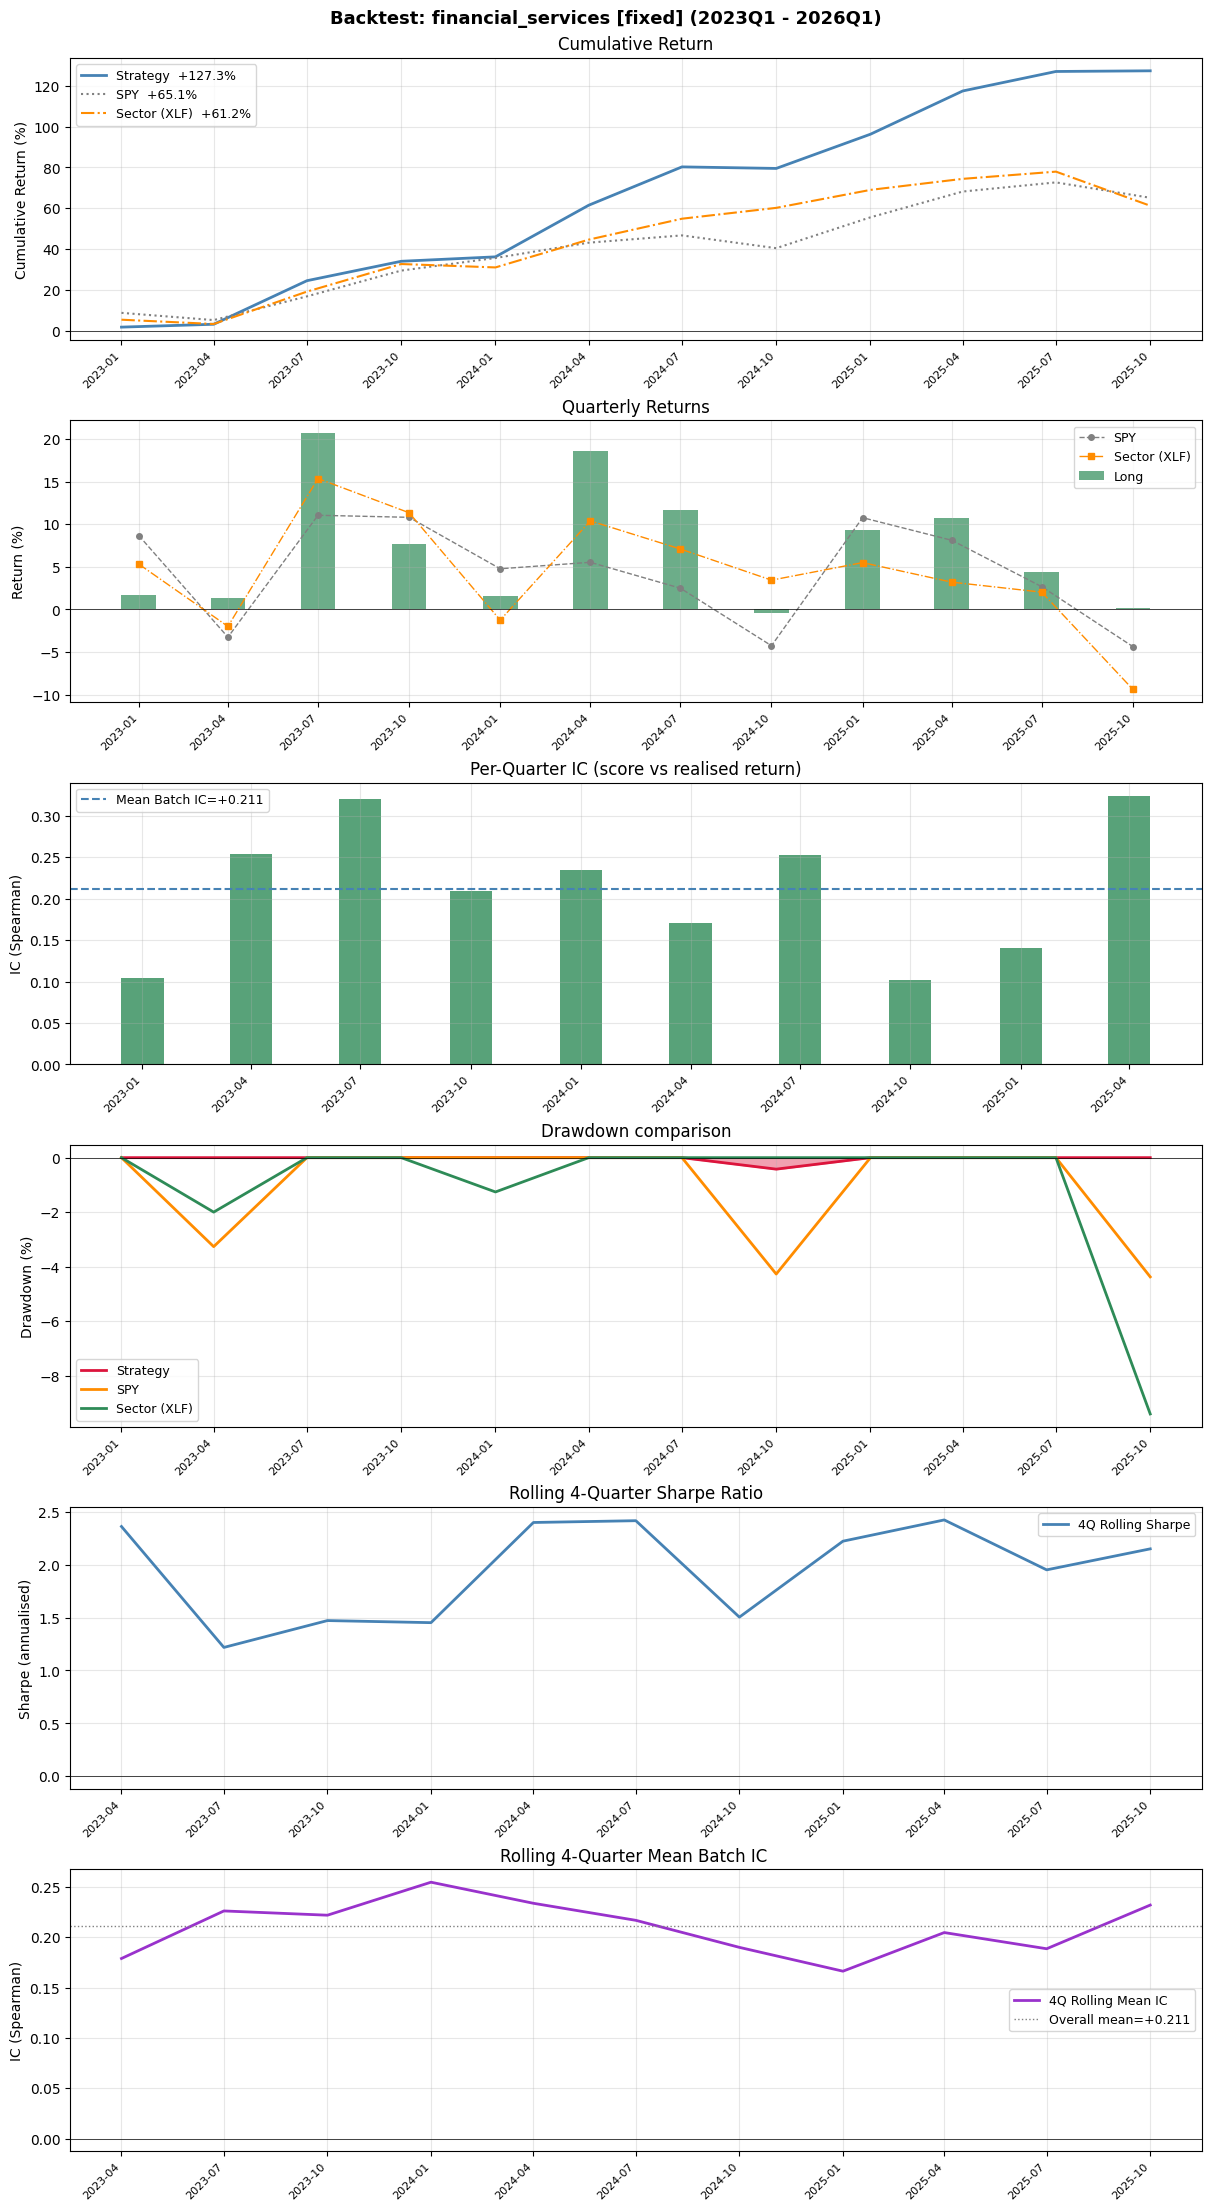

In [3]:
results = backtest_XGB.run_backtest(
    experiment_name = EXPERIMENT,
    sectors         = SECTORS,
    top_q           = TOP_QUANTILE,
    bot_q           = BOT_QUANTILE,
    start_date      = START,
    end_date        = END,
    rebalance_mode  = REBALANCE,
    min_stocks      = MIN_STOCKS,
    output_dir      = OUTPUT_DIR,
)

In [ ]:
from pathlib import Path
import backtest_MLP

EXPERIMENT    = "healthcare_mlp"       # matches results_mlp/final_<NAME>_mlp_*.joblib
SECTORS       = ["healthcare"]         # None = all sectors
TOP_QUANTILE  = 0.2
BOT_QUANTILE  = 0.0                    # 0 = long-only
REBALANCE     = "fixed"                # "fixed" | "staggered"
MIN_STOCKS    = 3
OUTPUT_DIR    = Path("backtest_results_mlp")

df = backtest_MLP.load_dataset(SECTORS)
START, END = backtest_MLP.infer_test_window(df, test_months=24)
print(f"Test window: {START}  →  {END}")

In [ ]:
results = backtest_MLP.run_backtest(
    experiment_name = EXPERIMENT,
    sectors         = SECTORS,
    top_q           = TOP_QUANTILE,
    bot_q           = BOT_QUANTILE,
    start_date      = START,
    end_date        = END,
    rebalance_mode  = REBALANCE,
    min_stocks      = MIN_STOCKS,
    output_dir      = OUTPUT_DIR,
)